<a href="https://colab.research.google.com/github/Janmeshree/ML-PRACS/blob/main/ML_MULTI_PERCEPTRON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import mean_squared_error

In [22]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [23]:
features = ['mean radius', 'mean texture']

X = df[features].values.astype(float)
y = df['diagnosis'].values

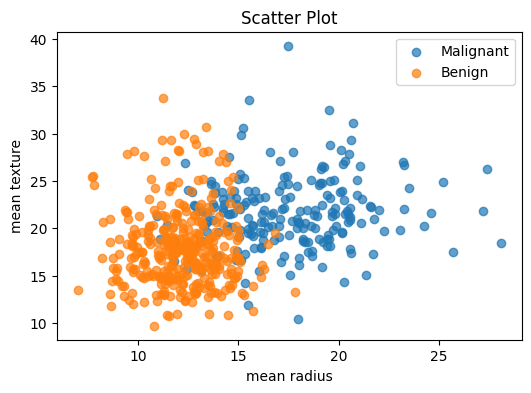

In [24]:
plt.figure(figsize=(6,4))

for label, name in zip([0,1], ['Malignant','Benign']):
    plt.scatter(X[y==label][:,0], X[y==label][:,1],
                label=name, alpha=0.7)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title("Scatter Plot")
plt.legend()
plt.show()

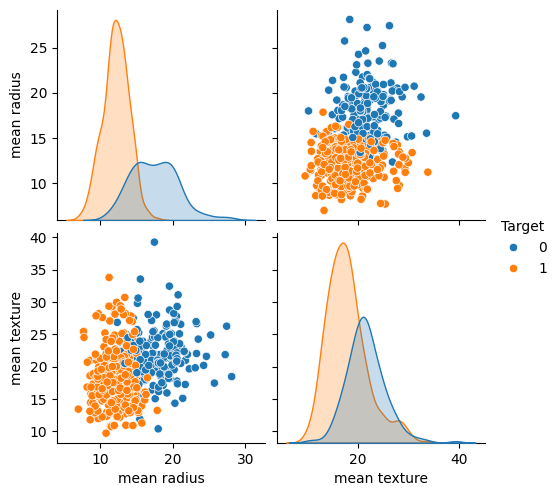

In [25]:
sns.pairplot(pd.DataFrame(X, columns=features).assign(Target=y),
             hue='Target', diag_kind='kde')
plt.show()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
mlp = MLPClassifier(hidden_layer_sizes=(5,),
                    activation='relu',
                    solver='adam',
                    max_iter=500,
                    random_state=42)

mlp.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(5,), max_iter=500, random_state=42)

In [28]:
y_prob = mlp.predict_proba(X_train_scaled)[:,1]

mse = mean_squared_error(y_train, y_prob)
print("MSE:", mse)

MSE: 0.09183110635091611


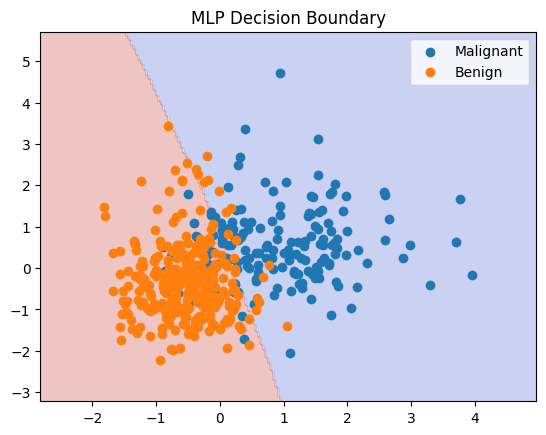

In [29]:
x_min, x_max = X_train_scaled[:,0].min()-1, X_train_scaled[:,0].max()+1
y_min, y_max = X_train_scaled[:,1].min()-1, X_train_scaled[:,1].max()+1

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

for label, name in zip([0,1], ['Malignant','Benign']):
    plt.scatter(X_train_scaled[y_train==label][:,0],
                X_train_scaled[y_train==label][:,1],
                label=name)

plt.title("MLP Decision Boundary")
plt.legend()
plt.show()